In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn import preprocessing
from scipy.spatial.distance import pdist, squareform
from scipy import cluster
from matplotlib.lines import Line2D
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans

ModuleNotFoundError: No module named 'seaborn'

# **Tarea 1: Creación y carga del dataset, análisis estadístico.**

*   1.1. Crea el dataset con el código adjunto y cárgalo en un array llamado circulos. Crea un dataframe llamado df_circulos, que contenga las columnas X e Y de circulos y una columna añadida con el nombre distancia, dicha columna contendrá la distancia euclídea de cada punto al origen de coordenadas. [0,0].
*   1.2. Realiza un estudio estadístico descriptivo de df_circulos. Genera un gráfico estadístico dondese vean las distancias agrupadas de los puntos al origen [0,0].
*   1.3. Comenta los resultados.

In [ ]:
# 1.1. Crea el dataset con el código adjunto y cárgalo en un array llamado circulos. Crea un dataframe llamado df_circulos,
# que contenga las columnas X e Y de circulos y una columna añadida con el nombre distancia,
# dicha columna contendrá la distancia euclídea de cada punto al origen de coordenadas. [0,0].

def generar_círculos_con_densidad_variable(radio_densidad_map, ruido=0.1):
# Genera círculos concéntricos con densidades variables.
#
# Args:
# radio_densidad_map (dict): Diccionario {radio: cantidad_de_puntos}
# ruido (float): Desviación estándar del ruido gaussiano.
#
# Returns:
# X (np.ndarray): Datos de forma (n_puntos, 2)
# y (np.ndarray): Etiquetas de clase (círculo) para cada punto
    np.random.seed(56)
    X = []
    y = []
    for i, (radio, n_puntos) in enumerate(radio_densidad_map.items()):
      angulos = np.random.uniform(0, 2 * np.pi, n_puntos)
      x = radio * np.cos(angulos) + np.random.normal(0, ruido, n_puntos)
      y_ = radio * np.sin(angulos) + np.random.normal(0, ruido, n_puntos)
      X.extend(zip(x, y_))
      y.extend([i] * n_puntos)
    return np.array(X), np.array(y)

# Configuración: círculo interior más denso, exterior menos denso
radio_densidad_map = {
 1: 1000, # círculo interior
 4: 750, # círculo medio
 7: 300 # círculo exterior
}

circulos, y = generar_círculos_con_densidad_variable(radio_densidad_map,
ruido=0.3)

# Crear DataFrame con columnas X, Y
df_circulos = pd.DataFrame(circulos, columns=['X', 'Y'])

# Calcular la distancia euclídea al origen y añadirla como nueva columna
df_circulos['distancia'] = np.sqrt(df_circulos['X']**2 + df_circulos['Y']**2)

# Mostrar las primeras filas del DataFrame
print(df_circulos.head())

          X         Y  distancia
0  0.695087  0.211759   0.726628
1 -0.233626  0.959980   0.987999
2 -0.499010 -0.351201   0.610207
3  0.695363  0.829677   1.082541
4 -0.465488  0.654058   0.802790


Estadísticas descriptivas de los circulos:
                 X            Y    distancia
count  2050.000000  2050.000000  2050.000000
mean      0.001066     0.022289     2.990412
std       2.613061     2.611980     2.168893
min      -7.713997    -7.549423     0.117734
25%      -1.020480    -1.054298     1.032857
50%       0.052334     0.049118     3.418525
75%       1.044572     1.114056     4.177602
max       7.571986     7.532232     7.851310




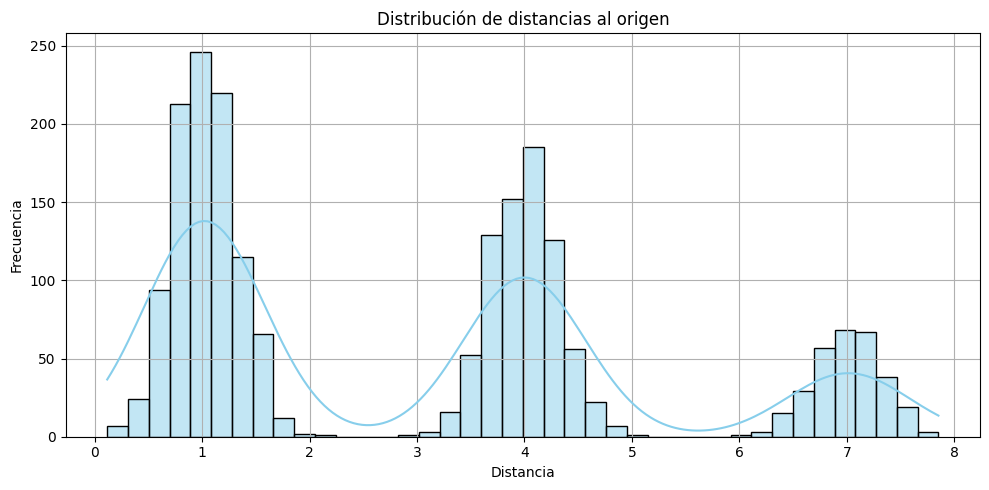

In [ ]:
# 1.2. Realiza un estudio estadístico descriptivo de df_circulos. Genera un gráfico estadístico dondese vean las distancias
# agrupadas de los puntos al origen [0,0].

# Estadísticas descriptivas
print("Estadísticas descriptivas de los circulos:")
print(df_circulos.describe())
print("\n")

# Gráfico estadístico: distribución de distancias
plt.figure(figsize=(10, 5))
sns.histplot(df_circulos['distancia'], bins=40, kde=True, color='skyblue', edgecolor='black')
plt.title("Distribución de distancias al origen")
plt.xlabel("Distancia")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()


1.3. Comenta los resultados.

* El histograma presenta tres agrupaciones principales, que corresponden a los radios especificados en el dataset: aproximadamente en 1, 4 y 7 unidades de distancia al origen.

* Cada pico representa un grupo de puntos alrededor de uno de esos radios, es decir, los tres círculos generados.

* El pico más alto se encuentra cerca del radio 1, lo cual es coherente con que ese círculo tiene la mayor cantidad de puntos (1000).

* El segundo pico se encuentra cerca del radio 4, es un poco más bajo, correspondiente al círculo medio con 750 puntos.

* El pico más bajo se encuentra cerca del radio 7, representa el círculo externo, que tiene solo 300 puntos.

# **Tarea 2: Entrenamiento con DBSCAN.**

*   2.1. Haz un estudio del comportamiento de DBSCAN con el dataset circulos, probando, al menos,
los siguientes valores de eps y min_pts:
a. eps: 0.3, 0.5, 0.7, 0.9, 1.1, 1.3
b. min_pts: 2, 3, 5, 7
*   2.2. Muestra una tabla donde en cada fila aparezca: valor de eps, valor de min_pts, nº de grupos
obtenidos, nº de outliers obtenidos.
*   2.3. Haz una representación gráfica de los resultados obtenidos, de la siguiente manera:
 Muestra una fila de gráficos por cada valor de eps.
 En cada fila, muestra los gráficos correspondientes a los distintos valores de min_pts probados.
 En cada gráfico, correspondiente a un eps y un min_pts, debe aparecer como título el valor de eps, el valor de min_pts, el nº de clusters obtenidos y el nº de outliers detectados, al estilo de como se muestra en esta figura:
*   2.4. En un cuadro de texto comenta los resultados obtenidos y analízalos.
*   2.5. Elige aquellos hiperparámetros que detecten los tres círculos por separado y con el menor
número posible de outliers. Entrena de nuevo ese caso y muestra un gráfico con los
resultados obtenidos, al estilo de lo realizado en el aparato 2.3.
*   2.6. Añade una columna llamada dbscan al dataframe df_circulos, que contendrá el grupo
asignado al elemento por este algoritmo. Muestra el dataframe completo.



In [ ]:
# 2.1. Haz un estudio del comportamiento de DBSCAN con el dataset circulos, probando, al menos,
# los siguientes valores de eps y min_pts:
# a. eps: 0.3, 0.5, 0.7, 0.9, 1.1, 1.3
# b. min_pts: 2, 3, 5, 7

# Rango de valores
eps_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]
min_pts_values = [2, 3, 5, 7]

# Almacenar resultados
resultados = []

# Ejecutar DBSCAN para cada combinación
for eps in eps_values:
    for min_pts in min_pts_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_pts)
        etiquetas = dbscan.fit_predict(circulos)

        n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
        n_outliers = list(etiquetas).count(-1)

        resultados.append({
            'eps': eps,
            'min_pts': min_pts,
            'n_clusters': n_clusters,
            'n_outliers': n_outliers
        })

# Crear DataFrame resumen
df_resultados = pd.DataFrame(resultados)

In [ ]:
# 2.2. Muestra una tabla donde en cada fila aparezca: valor de eps, valor de min_pts, nº de grupos obtenidos, nº de outliers obtenidos.

# Mostrar resultados
df_resultados.head()

,eps,min_pts,n_clusters,n_outliers
0,0.3,2,64,96
1,0.3,3,37,150
2,0.3,5,13,296
3,0.3,7,10,383
4,0.5,2,17,14


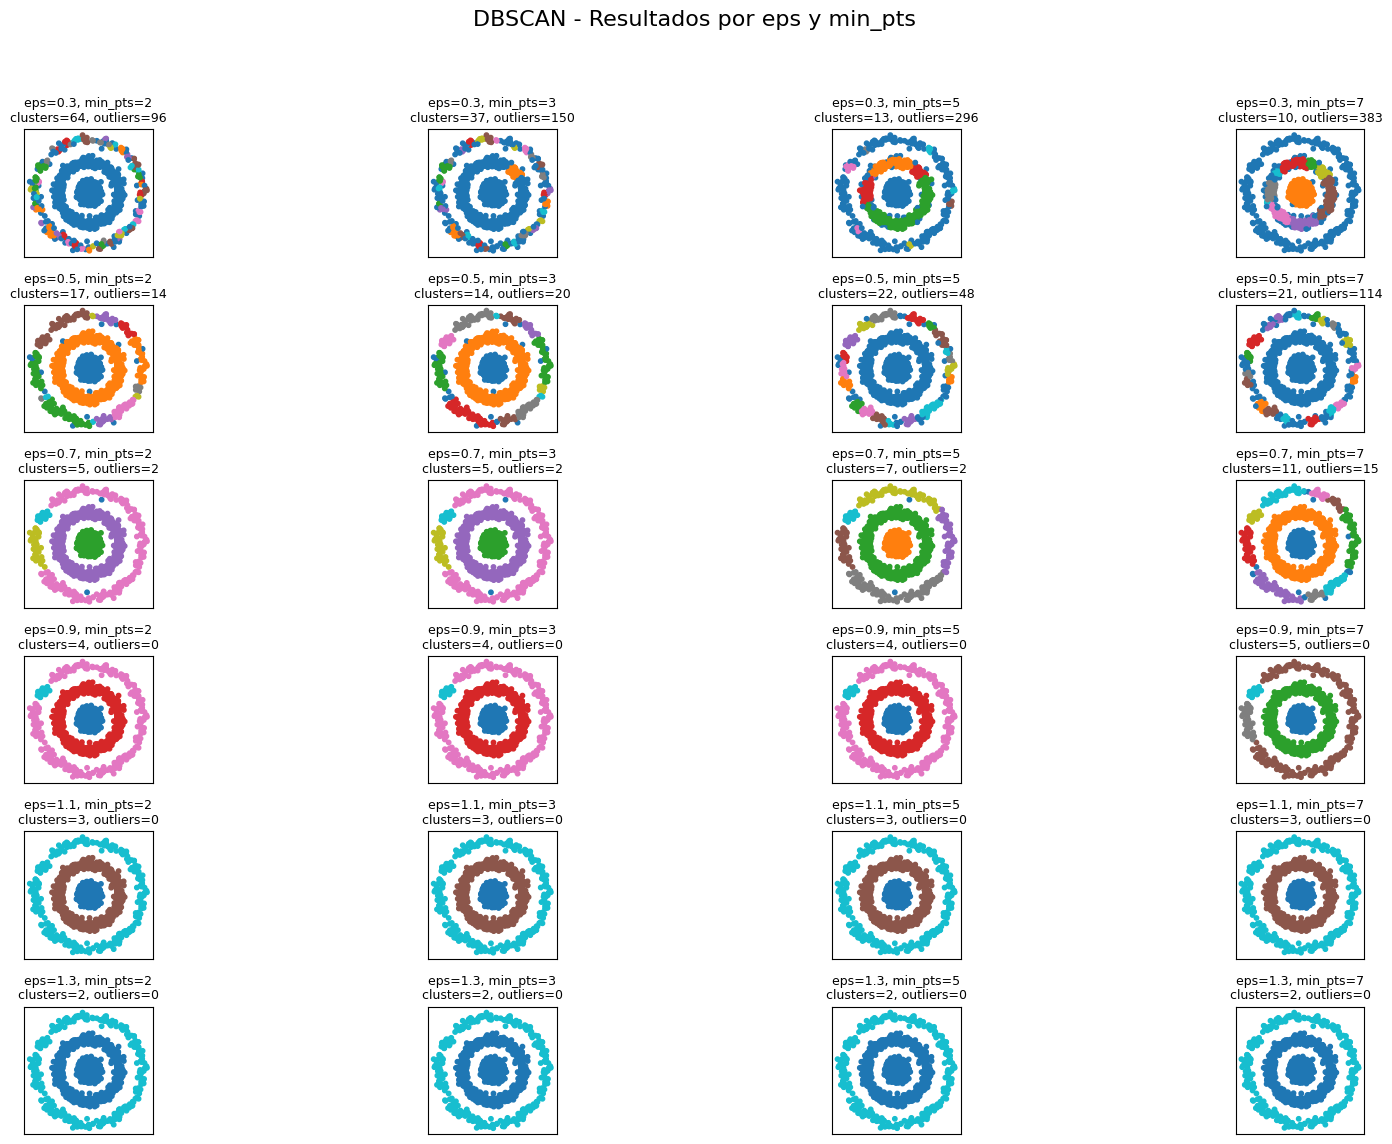

In [ ]:
# 2.3. Haz una representación gráfica de los resultados obtenidos, de la siguiente manera:
# - Muestra una fila de gráficos por cada valor de eps.
# - En cada fila, muestra los gráficos correspondientes a los distintos valores de min_pts probados.
# - En cada gráfico, correspondiente a un eps y un min_pts, debe aparecer como título el valor de eps,
# el valor de min_pts, el nº de clusters obtenidos y el nº de outliers detectados.

# Crear figura de subplots
fig, axes = plt.subplots(len(eps_values), len(min_pts_values), figsize=(18, 12))
fig.suptitle("DBSCAN - Resultados por eps y min_pts", fontsize=16)

# Repetimos evaluación con visualización
for row_idx, eps in enumerate(eps_values):
    for col_idx, min_pts in enumerate(min_pts_values):
        db = DBSCAN(eps=eps, min_samples=min_pts)
        etiquetas = db.fit_predict(circulos)

        n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
        n_outliers = list(etiquetas).count(-1)

        ax = axes[row_idx, col_idx]
        scatter = ax.scatter(circulos[:, 0], circulos[:, 1], c=etiquetas, cmap="tab10", s=10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"eps={eps}, min_pts={min_pts}\nclusters={n_clusters}, outliers={n_outliers}", fontsize=9)
        ax.grid(True)
        ax.set_aspect('equal')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

2.4. En un cuadro de texto comenta los resultados obtenidos y analízalos.

---
eps = 0.5 (fila 1) y eps = 0.7 (fila 2):

* Todos los valores de min_pts (2, 3, 5, 7) producen una cantidad excesiva de clústeres.

* El algoritmo tiende a sobreajustarse: se crean muchos grupos pequeños, reflejando una alta sensibilidad a pequeños cambios locales.
---
eps = 0.9 (fila 3):

* Se estabiliza el número de clústeres: 4 o 5 clústeres, sin outliers.

* Este valor de eps parece estar en un punto óptimo: detecta los círculos casi correctamente (puede dividir uno en dos por la variación en densidad).

* Resultados muy consistentes independientemente de min_pts.
---
eps = 1.1 (fila 4):

* Se detectan exactamente 3 clústeres en todos los casos, sin outliers.

* DBSCAN con eps=1.1 y cualquier min_pts >= 2 es el más preciso.
---
eps = 1.3 (fila 5):

* Solo se detectan 2 clústeres, lo que indica que los círculos más internos y medios han sido absorbidos en un único grupo.

* Es una muestra de sobreagrupamiento: al ampliar demasiado eps, DBSCAN une clústeres.
---

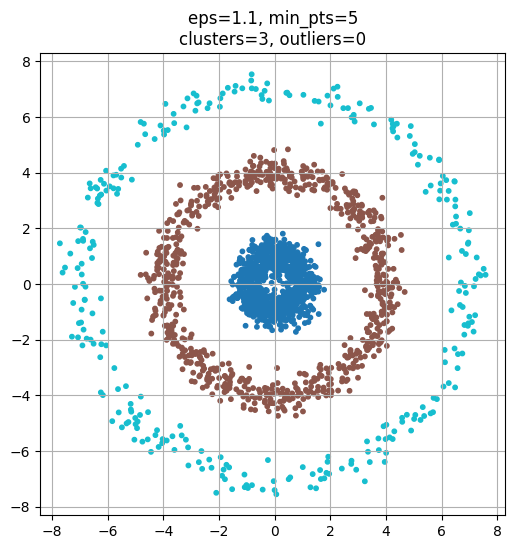

In [ ]:
# 2.5.Elige aquellos hiperparámetros que detecten los tres círculos por separado y con el menor
# número posible de outliers. Entrena de nuevo ese caso y muestra un gráfico con los
# resultados obtenidos, al estilo de lo realizado en el aparato 2.3.

# DBSCAN
db = DBSCAN(eps=1.1, min_samples=5)
etiquetas = db.fit_predict(circulos)

n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
n_outliers = list(etiquetas).count(-1)

# Gráfico
plt.figure(figsize=(6, 6))
plt.scatter(circulos[:, 0], circulos[:, 1], c=etiquetas, cmap="tab10", s=10)
plt.title(f"eps=1.1, min_pts=5\nclusters={n_clusters}, outliers={n_outliers}", fontsize=12)
plt.grid(True)
plt.axis("equal")
plt.show()

In [ ]:
# 2.6.Añade una columna llamada dbscan al dataframe df_circulos, que contendrá el grupo
# asignado al elemento por este algoritmo. Muestra el dataframe completo.

# Entrenamiento DBSCAN con los mejores hiperparámetros
db = DBSCAN(eps=1.1, min_samples=5)
etiquetas_dbscan = db.fit_predict(circulos)

# Añadir columna con etiquetas de los clústeres
df_circulos['dbscan'] = etiquetas_dbscan

In [ ]:
# Círculo exterior (1000)
df_circulos[df_circulos['dbscan']==0]

,X,Y,distancia,dbscan
0,0.695087,0.211759,0.726628,0
1,-0.233626,0.959980,0.987999,0
2,-0.499010,-0.351201,0.610207,0
3,0.695363,0.829677,1.082541,0
4,-0.465488,0.654058,0.802790,0
...,...,...,...,...
995,-0.311064,-0.209427,0.374994,0
996,-0.402663,-0.406187,0.571949,0
997,0.737491,1.013127,1.253124,0
998,1.172178,0.332532,1.218433,0


In [ ]:
# Círculo exterior (750)
df_circulos[df_circulos['dbscan']==1]

,X,Y,distancia,dbscan
1000,1.143743,4.156764,4.311246,1
1001,-1.618683,3.658211,4.000331,1
1002,1.417114,4.285614,4.513834,1
1003,-1.036468,-3.476345,3.627567,1
1004,3.926536,-0.950623,4.039972,1
...,...,...,...,...
1745,-0.982251,3.488653,3.624296,1
1746,-2.276856,3.047558,3.804166,1
1747,3.808459,0.878799,3.908535,1
1748,3.789489,0.817465,3.876658,1


In [ ]:
# Círculo exterior (300)
df_circulos[df_circulos['dbscan']==2]

,X,Y,distancia,dbscan
1750,6.953661,-1.412135,7.095599,2
1751,-6.904104,-2.204094,7.247391,2
1752,-4.750487,-5.659757,7.389180,2
1753,4.886677,5.671852,7.486623,2
1754,0.058459,-7.549423,7.549650,2
...,...,...,...,...
2045,4.010475,-5.054344,6.452155,2
2046,-1.682426,7.046522,7.244586,2
2047,6.652698,-0.752570,6.695129,2
2048,-7.713997,1.461955,7.851310,2


# **Tarea 3: Entrenamiento con Algoritmo Jerárquico.**
* 3.1.Entrena el datset circulos, con el algoritmo jerárquico visto en clase y muestra el
dendograma.
* 3.2.Elige un umbral adecuado para que se obtengan 3 grupos y representa gráficamente el
resultado obtenido de forma que cumpla estos requisitos:
 * a. Representa cada elemento con un color en función del grupo al que pertenece.
 * b. El gráfico debe tener el siguiente título en la parte superior: Dataset circulos
agrupado con algoritmo jerárquico.
 * c. El gráfico debe tener una leyenda en la parte superior derecha.
 * d. El gráfico debe tener una línea inferior donde indique el valor de umbral elegido.
* 3.3.Añade una columna llamada jerarquico al dataframe df_circulos, que contendrá el grupo
asignado al elemento por este algoritmo. Muestra el dataframe completo.
* 3.4.En un cuadro de texto comenta los resultados obtenidos y analízalos.

<ipython-input-12-393fec713ba7>:16: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  clusters = cluster.hierarchy.linkage(D, method='complete')


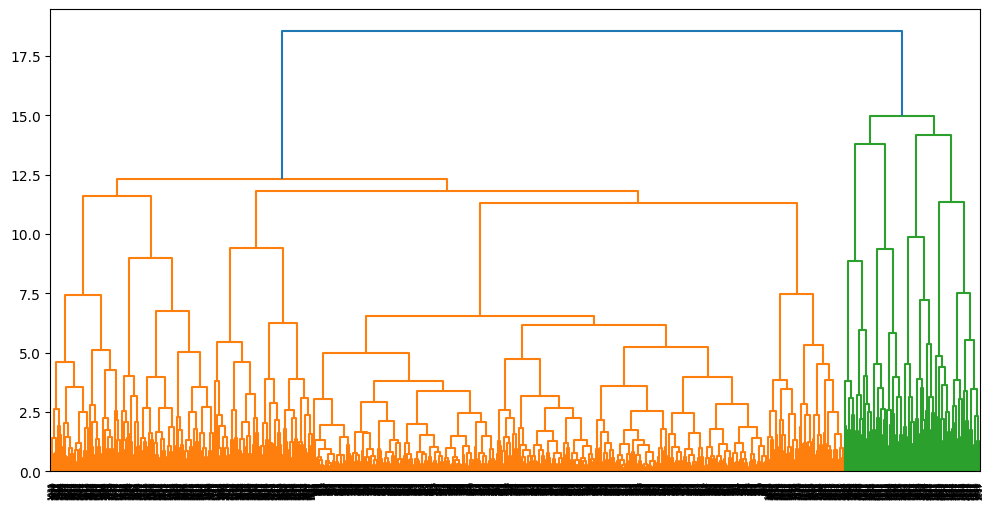

In [ ]:
# 3.1.Entrena el datset circulos, con el algoritmo jerárquico visto en clase y muestra el
# dendograma.

# Escalar
min_max_scaler = preprocessing.MinMaxScaler()
circulos_scaled = min_max_scaler.fit_transform(circulos)

## Clustering jerárquico
# Obtener la matriz de distancia entre todos los elementos
D = squareform(pdist(circulos_scaled, metric='euclidean'))
avD = np.average(D)

# Constuimos el dendograma
plt.figure(figsize=(12, 6))
# Seleccionamos como distancia intercluster el vecino más alejado (complete)
clusters = cluster.hierarchy.linkage(D, method='complete')
cluster.hierarchy.dendrogram(clusters, color_threshold=15)
plt.show()

In [ ]:
# 3.2.Elige un umbral adecuado para que se obtengan 3 grupos y representa gráficamente el
# resultado obtenido.

# Obtenemos el grupo al que pertenece cada observación
threshold = 3
# grupos
grupos = cluster.hierarchy.fcluster(clusters, threshold, criterion='maxclust')
# Número de clusters
print("Número de clusters {}".format(len(set(grupos))))
grupos

Número de clusters 3


array([1, 1, 1, ..., 2, 3, 2], dtype=int32)

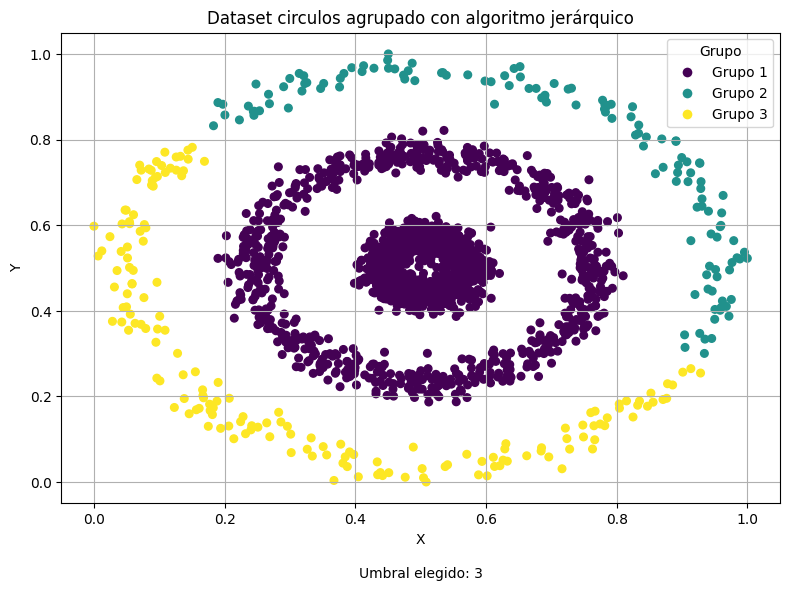

In [ ]:
plt.figure(figsize=(8, 6))

# Crear scatter plot y guardar el objeto para acceder al cmap y norm
scatter = plt.scatter(
    circulos_scaled[:, 0],
    circulos_scaled[:, 1],
    c=grupos,
    cmap='viridis',
    s=30
)

# Título y etiquetas
plt.title('Dataset circulos agrupado con algoritmo jerárquico')
plt.xlabel('X')
plt.ylabel('Y')

unique_groups = np.unique(grupos)
colors = scatter.cmap(scatter.norm(unique_groups))

# Crear leyenda
legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Grupo {g}',
                          markerfacecolor=c, markersize=8)
                   for g, c in zip(unique_groups, colors)]

plt.legend(handles=legend_elements, title="Grupo", loc='upper right')

# Mostrar el valor del umbral abajo como texto
plt.text(0.5, -0.15, f'Umbral elegido: {threshold}',
         ha='center', va='center', transform=plt.gca().transAxes)

plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# 3.3.Añade una columna llamada jerarquico al dataframe df_circulos, que contendrá el grupo
# asignado al elemento por este algoritmo. Muestra el dataframe completo.

df_circulos['jerarquico'] = grupos
df_circulos

,X,Y,distancia,dbscan,jerarquico
0,0.695087,0.211759,0.726628,0,1
1,-0.233626,0.959980,0.987999,0,1
2,-0.499010,-0.351201,0.610207,0,1
3,0.695363,0.829677,1.082541,0,1
4,-0.465488,0.654058,0.802790,0,1
...,...,...,...,...,...
2045,4.010475,-5.054344,6.452155,2,3
2046,-1.682426,7.046522,7.244586,2,2
2047,6.652698,-0.752570,6.695129,2,2
2048,-7.713997,1.461955,7.851310,2,3


3.4. En un cuadro de texto comenta los resultados obtenidos y analízalos.

Dado que el algoritmo jerárquico no utiliza información previa sobre la forma de los datos, en algunos casos los bordes de los clusters no son perfectamente definidos y hay cierta mezcla de puntos entre grupos contiguos.

# **Tarea 4: Entrenamiento con KMeans con truco de núcleo.**
* 4.1. Entrena el dataset circulos, con KMeans usando espacios de Hilbert con núcleo reproductor
(RHKS). Ten en cuenta estas directrices:
 * a. Se sabe que hay 3 grupos, no se probarán más opciones de número de grupos.
 * b. No se calcularán outliers influyentes.
 * c. Realiza pruebas de agrupamiento con distintos valores de gamma, al menos 6.
* 4.2. Haz una representación gráfica de los resultados obtenidos, de la siguiente manera:
 * a. Representa cada elemento con un color en función del grupo al que pertenece.
Representará también los centroides de los grupos con una forma y color distintos a
los de los elementos.
 * b. El gráfico debe tener el siguiente título en la parte superior: Dataset circulos
agrupado con KMEans+RHKS.
 * c. El gráfico debe tener una leyenda en la parte superior derecha.
 * d. El gráfico debe mostrar, en su parte inferior, los valores de los centroides.
* 4.3. Añade una columna llamada KMeansRHKS al dataframe df_circulos, que contendrá el grupo
asignado al elemento por este algoritmo. Muestra el dataframe completo.
* 4.4. En un cuadro de texto comenta los resultados obtenidos y analízalos.

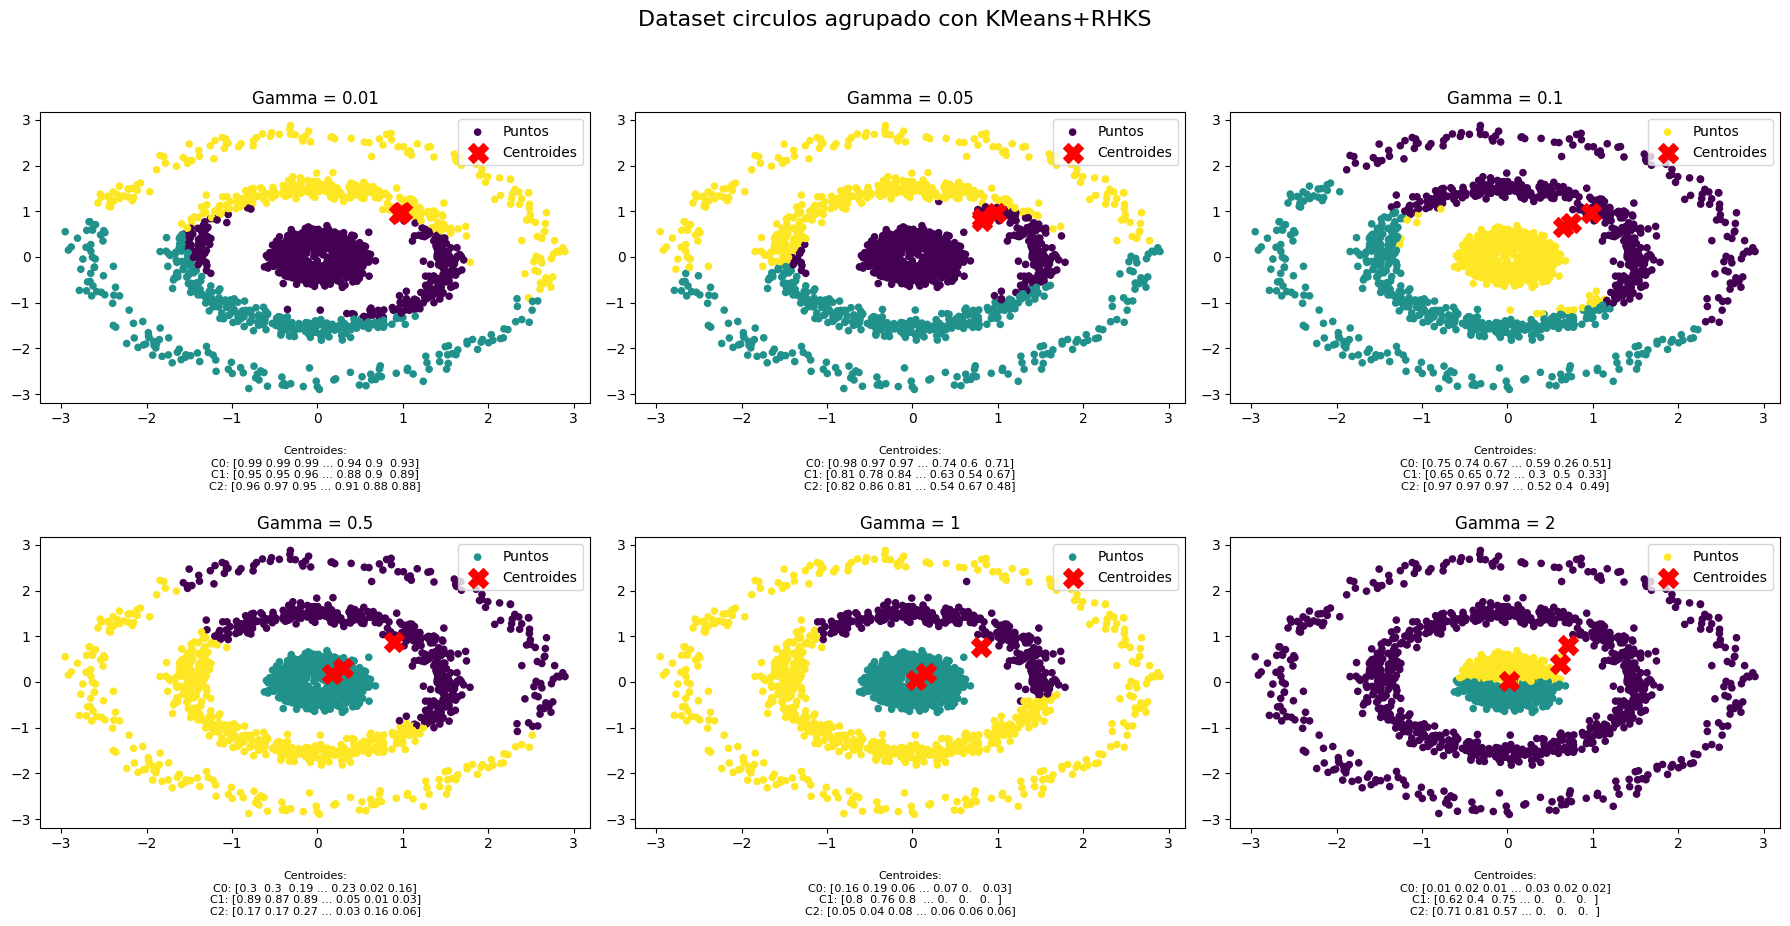

In [ ]:
# 4.1. Entrena el dataset circulos, con KMeans usando espacios de Hilbert con núcleo reproductor (RHKS).
# 4.2.Haz una representación gráfica de los resultados obtenidos

# Escalar el dataset
scaler = preprocessing.StandardScaler()
circulos_standard_scaled = scaler.fit_transform(circulos)

# Prueba con distintos valores de gamma
gammas = [0.01, 0.05, 0.1, 0.5, 1, 2]
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.ravel()

for i, gamma in enumerate(gammas):
    K = rbf_kernel(circulos_standard_scaled, gamma=gamma)

    kmeans = KMeans(n_clusters=3, random_state=0)
    kmeans.fit(K)

    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_

    axs[i].scatter(circulos_standard_scaled[:, 0], circulos_standard_scaled[:, 1], c=labels, cmap='viridis', s=20, label='Puntos')
    axs[i].scatter(centroids[:, 0], centroids[:, 1], marker='X', c='red', s=200, label='Centroides')
    axs[i].set_title(f"Gamma = {gamma}")
    axs[i].legend(loc='upper right')

    centroid_text = "\n".join([f"C{j}: {np.round(c, 2)}" for j, c in enumerate(centroids)])
    axs[i].text(0.5, -0.15, f"Centroides:\n{centroid_text}",
                ha='center', va='top', transform=axs[i].transAxes, fontsize=8)

plt.suptitle("Dataset circulos agrupado con KMeans+RHKS", fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [ ]:
# Usar un valor específico de gamma para generar columna en el DataFrame
# Usamos gamma=1 como ejemplo
gamma_final = 0.1
K_final = rbf_kernel(circulos_standard_scaled, gamma=gamma_final)
kmeans_final = KMeans(n_clusters=3, random_state=0)
df_circulos['KMeansRHKS'] = kmeans_final.fit_predict(K_final)

df_circulos

,X,Y,distancia,dbscan,jerarquico,KMeansRHKS
0,0.695087,0.211759,0.726628,0,1,2
1,-0.233626,0.959980,0.987999,0,1,2
2,-0.499010,-0.351201,0.610207,0,1,2
3,0.695363,0.829677,1.082541,0,1,2
4,-0.465488,0.654058,0.802790,0,1,2
...,...,...,...,...,...,...
2045,4.010475,-5.054344,6.452155,2,3,1
2046,-1.682426,7.046522,7.244586,2,2,0
2047,6.652698,-0.752570,6.695129,2,2,0
2048,-7.713997,1.461955,7.851310,2,3,1


4.4. En un cuadro de texto comenta los resultados obtenidos y analízalos.

Los grupos generados por KMeans no han logrado capturar adecuadamente la forma de los círculos. En todos los casos, los clusters dividen los anillos aproximadamente por la mitad, generando separaciones lineales que no se ajustan a la estructura curva original. Esto se debe a que KMeans, incluso cuando se aplica sobre la matriz de similitud generada por el kernel RBF, no realiza una verdadera partición en un espacio transformado, sino que agrupa basándose en patrones de similitud sin coordenadas explícitas.

# **Tarea 5: Comparación de resultados.**
* 5.1. Añade al final del todo un bloque de texto donde compares los tres algoritmos. Indica
claramente, al menos:
 * a. Cuál es el ámbito de aplicación fundamental de cada uno de los tres algoritmos
utilizados.
 * b. Qué algoritmos de los probados han sido capaces de agrupar por círculo y cuáles no
y porqué.
 * c. Por qué cada algoritmo ha sido bueno o malo para esta tarea.

a. Cuál es el ámbito de aplicación fundamental de cada uno de los tres algoritmos utilizados.
* DBSCAN (Density-Based Spatial Clustering of Applications with Noise):
Especializado en detectar clusters cuando hay ruido o densidad variable. Para datos con estructuras no lineales como anillos o espirales.

* Algoritmo Jerárquico:
Adecuado cuando se quiere explorar la estructura jerárquica de los datos. No impone suposiciones sobre la forma de los clusters, y permite decidir el número de grupos a posteriori mediante el análisis del dendrograma.

* KMeans con núcleo RBF (truco del núcleo):
Busca aplicar KMeans en un espacio no lineal utilizando una transformación implícita a través de una matriz de similitud. Útil en teoría para datos no lineales, pero en este caso, no.

b. Qué algoritmos de los probados han sido capaces de agrupar por círculo y cuáles no y porqué.
* DBSCAN: Sí agrupó correctamente por círculo.
Detectó perfectamente los tres anillos debido a su capacidad para identificar regiones de alta densidad separadas por zonas de baja densidad. No se ve afectado por la forma de los clusters, lo que lo hace ideal para este caso.

* Algoritmo Jerárquico: Agrupó razonablemente bien.
Aunque no usa directamente la forma de los datos, al elegir un umbral adecuado en el dendrograma, fue capaz de generar tres grupos que siguen en buena medida la estructura circular. Sin embargo, puede haber mezcla en los bordes entre anillos.

* KMeans con núcleo RBF: No agrupó correctamente.
La separación obtenida fue errónea: los clusters dividen los anillos por la mitad en lugar de respetar sus formas circulares.

c. Por qué cada algoritmo ha sido bueno o malo para esta tarea.
* DBSCAN fue el mejor porque está diseñado precisamente para este tipo de estructura no lineal. No necesita suposiciones sobre la forma o el número de clusters.

* El algoritmo jerárquico fue aceptable gracias a su flexibilidad y la ayuda visual del dendrograma, pero no es tan robusto cuando los clusters no están bien separados o hay ruido.

* KMeans con núcleo RBF falló porque el truco del núcleo no fue suficiente para modelar adecuadamente la geometría del problema.